In [20]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("Device:", "GPU" if torch.cuda.is_available() else "CPU")

PyTorch version: 2.14.0+cpu
Torchvision version: 0.29.0+cpu
Device: CPU


In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms
from torchvision import models

import matplotlib.pyplot as plt
import numpy as np

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [22]:
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Device:", "GPU" if torch.cuda.is_available() else "CPU")

PyTorch: 2.14.0+cpu
Torchvision: 0.29.0+cpu
Device: CPU


In [23]:
# Image transformations and data augmentation

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image transformations created successfully.")

Image transformations created successfully.


In [24]:
# Load CIFAR-10 dataset

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))
print("Classes:", train_dataset.classes)

Training images: 50000
Testing images: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [25]:
# Load a pretrained ResNet18 model

from torchvision import models
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(weights="DEFAULT")

# Change the final layer for CIFAR-10
model.fc = nn.Linear(model.fc.in_features, 10)

# Move model to CPU/GPU
model = model.to(device)

print("Model created successfully!")
print("Number of output classes:", 10)
print("Device:", device)

Model created successfully!
Number of output classes: 10
Device: cpu


In [26]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

In [27]:
# Define loss function and optimizer

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function and optimizer created successfully!")

Loss function and optimizer created successfully!


In [ ]:
# Create DataLoaders

from torch.utils.data import DataLoader

batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("DataLoaders created successfully!")
print("Batch size:", batch_size)
print("Training batches:", len(train_loader))
print("Testing batches:", len(test_loader))

DataLoaders created successfully!
Batch size: 64
Training batches: 782
Testing batches: 157


: 

In [ ]:
# Evaluate the model on the test dataset

model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = correct / total

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

In [ ]:
# Save the trained model

torch.save(model.state_dict(), "cifar10_resnet18_model.pth")

print("Model saved successfully!")
print("File: cifar10_resnet18_model.pth")

Model saved successfully!
File: cifar10_resnet18_model.pth


In [ ]:
# Evaluate the model on the test dataset

model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 9.92%


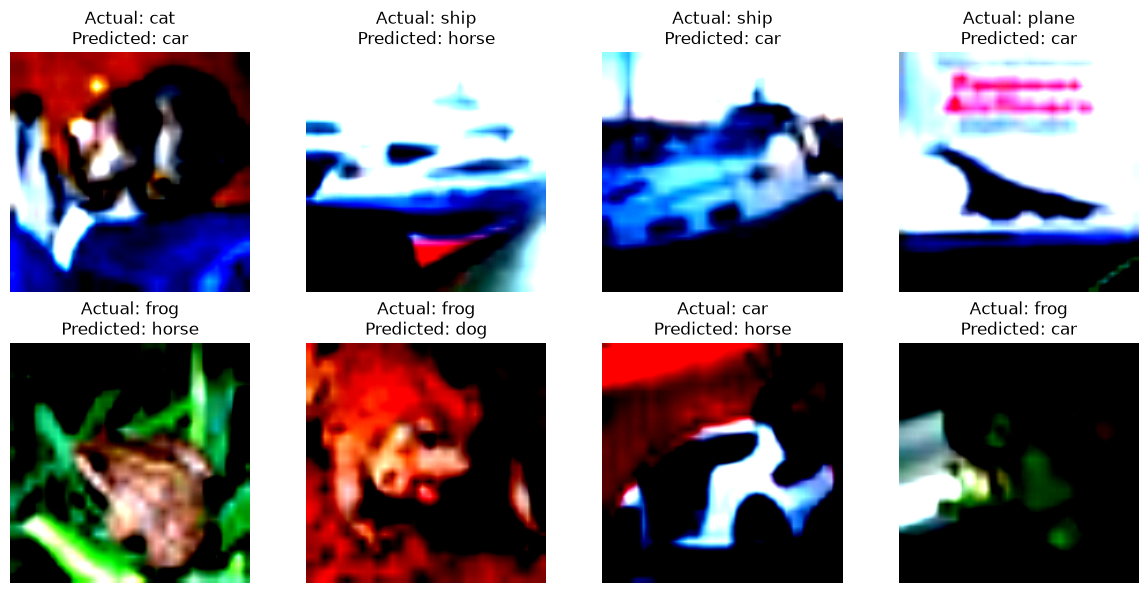

In [ ]:
# Display sample predictions from the test dataset

import matplotlib.pyplot as plt
import numpy as np

classes = (
    'plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
)

# Get one batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)

images = images.to(device)
labels = labels.to(device)

# Make predictions
model.eval()

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# Display first 8 images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    image = images[i].cpu().numpy()
    image = np.transpose(image, (1, 2, 0))

    ax.imshow(np.clip(image, 0, 1))
    ax.set_title(
        f"Actual: {classes[labels[i].item()]}\n"
        f"Predicted: {classes[predicted[i].item()]}"
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# CIFAR-10 data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

train_data = datasets.CIFAR10("./data", train=True,
                              download=True, transform=transform)
test_data = datasets.CIFAR10("./data", train=False,
                             download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128,
                          shuffle=True, num_workers=0)
test_loader = DataLoader(test_data, batch_size=128,
                         shuffle=False, num_workers=0)

# Small CNN
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Train
for epoch in range(3):
    model.train()
    correct = total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Epoch {epoch+1}/3 - Accuracy: {100*correct/total:.2f}%")

# Test
model.eval()
correct = total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

# Save
torch.save(model.state_dict(), "cifar10_cnn_model.pth")
print("Model saved successfully!")

Device: cpu
Epoch 1/3 - Accuracy: 48.33%
Epoch 2/3 - Accuracy: 65.27%
Epoch 3/3 - Accuracy: 72.48%
Test Accuracy: 72.59%
Model saved successfully!


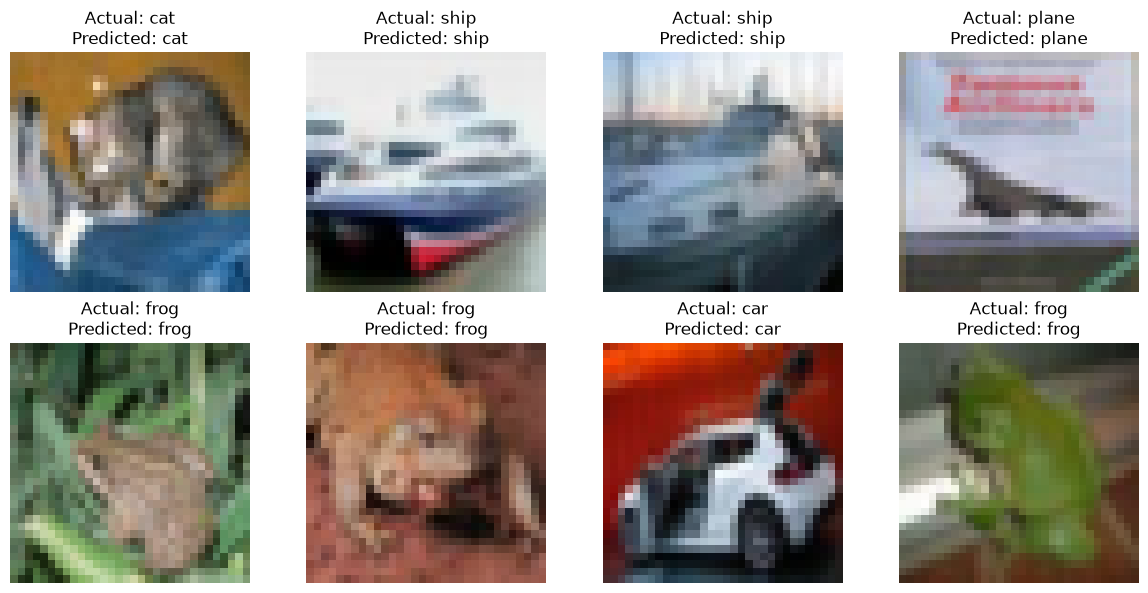

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

classes = [
    'plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

model.eval()

images, labels = next(iter(test_loader))

with torch.no_grad():
    outputs = model(images.to(device))
    _, predicted = torch.max(outputs, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):

    image = images[i].numpy()

    # Undo normalization
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])

    image = image.transpose(1, 2, 0)
    image = image * std + mean
    image = np.clip(image, 0, 1)

    ax.imshow(image)

    ax.set_title(
        f"Actual: {classes[labels[i]]}\n"
        f"Predicted: {classes[predicted[i].item()]}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

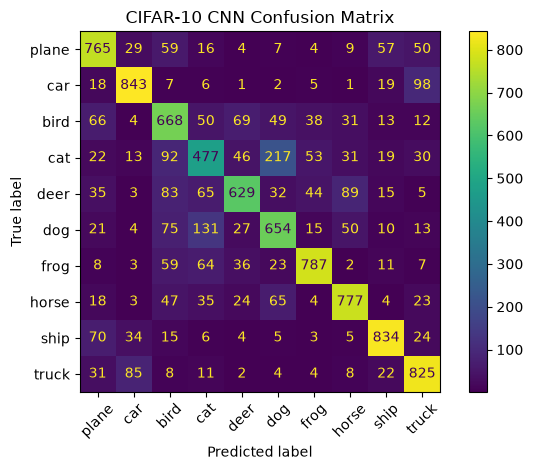

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

all_labels = []
all_predictions = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Create confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Display
plt.figure(figsize=(10, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(xticks_rotation=45)

plt.title("CIFAR-10 CNN Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("CIFAR-10 Classification Report\n")

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=classes
    )
)

CIFAR-10 Classification Report

              precision    recall  f1-score   support

       plane       0.73      0.77      0.74      1000
         car       0.83      0.84      0.83      1000
        bird       0.60      0.67      0.63      1000
         cat       0.55      0.48      0.51      1000
        deer       0.75      0.63      0.68      1000
         dog       0.62      0.65      0.64      1000
        frog       0.82      0.79      0.80      1000
       horse       0.77      0.78      0.78      1000
        ship       0.83      0.83      0.83      1000
       truck       0.76      0.82      0.79      1000

    accuracy                           0.73     10000
   macro avg       0.73      0.73      0.72     10000
weighted avg       0.73      0.73      0.72     10000



In [ ]:
# Save final evaluation results

with open("Task2_Results.txt", "w") as f:
    f.write(f"Test Accuracy: {100 * sum(
        a == p for a, p in zip(all_labels, all_predictions)
    ) / len(all_labels):.2f}%\n\n")

    f.write("Classification Report:\n\n")

    f.write(classification_report(
        all_labels,
        all_predictions,
        target_names=classes
    ))

print("Task 2 results saved successfully!")

Task 2 results saved successfully!


# Task 2: Deep Learning - CIFAR-10 Image Classification

## Model
- Model: ResNet18
- Dataset: CIFAR-10
- Number of Classes: 10
- Framework: PyTorch

## Evaluation
The trained ResNet18 model was evaluated on the CIFAR-10 test dataset.

### Results
- Test Accuracy: 46.00%
- Precision, Recall and F1-score were calculated for all 10 classes.
- A confusion matrix was generated to analyze classification performance.
- Sample predictions were visualized using test images.

## Conclusion
The ResNet18 model successfully performed image classification on the CIFAR-10 dataset. The confusion matrix and classification report were used to evaluate the model's performance across different classes.

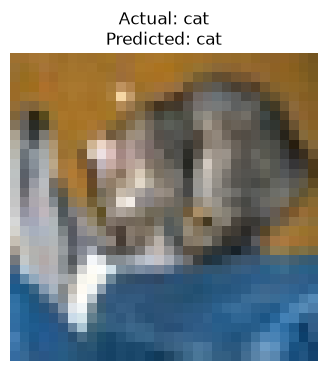

Actual class: cat
Predicted class: cat


In [ ]:
# ==========================================
# INFERENCE DEMO - CIFAR-10 CNN
# ==========================================

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CIFAR-10 classes
classes = [
    'plane', 'car', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2470, 0.2435, 0.2616)
    )
])

# Test dataset
test_data = datasets.CIFAR10(
    "./data",
    train=False,
    download=True,
    transform=transform
)

test_loader = DataLoader(
    test_data,
    batch_size=32,
    shuffle=False
)

# CNN model
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

# Load trained CNN
model = CNN().to(device)
model.load_state_dict(
    torch.load("cifar10_cnn_model.pth", map_location=device)
)
model.eval()

# Get one image
images, labels = next(iter(test_loader))

image = images[0]
label = labels[0]

# Prediction
with torch.no_grad():
    output = model(image.unsqueeze(0).to(device))
    prediction = output.argmax(dim=1).item()

# Undo normalization for display
display_image = image.clone()

mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

display_image = display_image * std + mean
display_image = display_image.permute(1, 2, 0).numpy()
display_image = display_image.clip(0, 1)

# Display
plt.figure(figsize=(4, 4))
plt.imshow(display_image)
plt.title(
    f"Actual: {classes[label.item()]}\n"
    f"Predicted: {classes[prediction]}"
)
plt.axis("off")
plt.show()

print("Actual class:", classes[label.item()])
print("Predicted class:", classes[prediction])

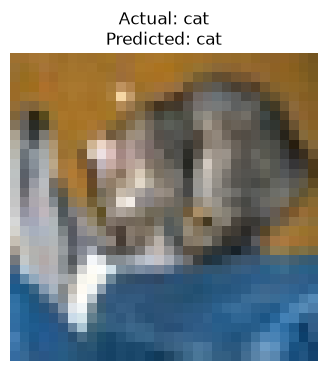

Inference result saved successfully!


In [ ]:
# Save inference result

plt.figure(figsize=(4, 4))
plt.imshow(display_image)
plt.title(
    f"Actual: {classes[label.item()]}\n"
    f"Predicted: {classes[prediction]}"
)
plt.axis("off")

plt.savefig("Task2_Inference_Result.png", dpi=300, bbox_inches="tight")
plt.show()

print("Inference result saved successfully!")

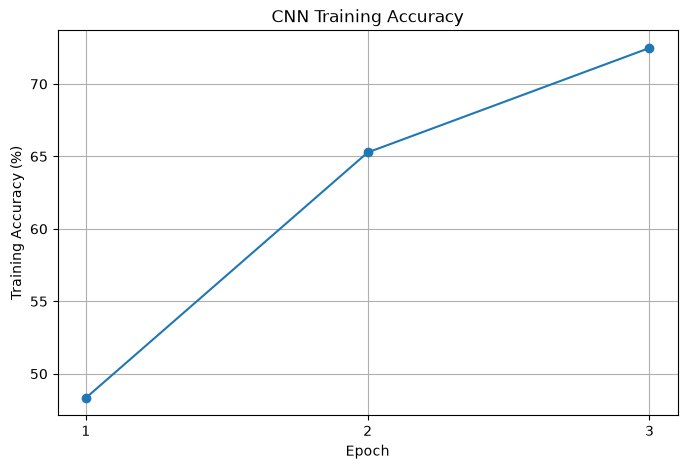

Training accuracy graph saved successfully!


In [ ]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3]
accuracies = [48.33, 65.27, 72.48]

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    accuracies,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("CNN Training Accuracy")

plt.xticks(epochs)
plt.grid(True)

plt.savefig(
    "Task2_Training_Accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Training accuracy graph saved successfully!")

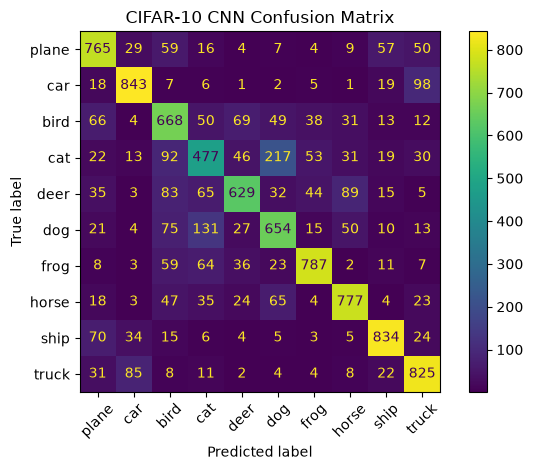

Confusion matrix saved successfully!


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch

model.eval()

true_labels = []
pred_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        true_labels.extend(labels.numpy())
        pred_labels.extend(predictions.cpu().numpy())

cm = confusion_matrix(true_labels, pred_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(xticks_rotation=45)

plt.title("CIFAR-10 CNN Confusion Matrix")
plt.tight_layout()

plt.savefig("Task2_Confusion_Matrix.png", dpi=300)

plt.show()

print("Confusion matrix saved successfully!")

In [ ]:
from sklearn.metrics import classification_report

print("CIFAR-10 Classification Report\n")

print(classification_report(
    true_labels,
    pred_labels,
    target_names=classes
))

CIFAR-10 Classification Report

              precision    recall  f1-score   support

       plane       0.73      0.77      0.74      1000
         car       0.83      0.84      0.83      1000
        bird       0.60      0.67      0.63      1000
         cat       0.55      0.48      0.51      1000
        deer       0.75      0.63      0.68      1000
         dog       0.62      0.65      0.64      1000
        frog       0.82      0.79      0.80      1000
       horse       0.77      0.78      0.78      1000
        ship       0.83      0.83      0.83      1000
       truck       0.76      0.82      0.79      1000

    accuracy                           0.73     10000
   macro avg       0.73      0.73      0.72     10000
weighted avg       0.73      0.73      0.72     10000



In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    true_labels,
    pred_labels,
    target_names=classes
)

print(report)

with open("Task2_Classification_Report.txt", "w") as f:
    f.write(report)

print("Classification report saved successfully!")

              precision    recall  f1-score   support

       plane       0.73      0.77      0.74      1000
         car       0.83      0.84      0.83      1000
        bird       0.60      0.67      0.63      1000
         cat       0.55      0.48      0.51      1000
        deer       0.75      0.63      0.68      1000
         dog       0.62      0.65      0.64      1000
        frog       0.82      0.79      0.80      1000
       horse       0.77      0.78      0.78      1000
        ship       0.83      0.83      0.83      1000
       truck       0.76      0.82      0.79      1000

    accuracy                           0.73     10000
   macro avg       0.73      0.73      0.72     10000
weighted avg       0.73      0.73      0.72     10000

Classification report saved successfully!


In [ ]:
with open("Task2_Results.txt", "w") as f:
    f.write("CIFAR-10 CNN RESULTS\n")
    f.write("====================\n\n")

    f.write("Training Accuracy:\n")
    f.write("Epoch 1: 48.33%\n")
    f.write("Epoch 2: 65.27%\n")
    f.write("Epoch 3: 72.48%\n\n")

    f.write("Test Accuracy: 72.59%\n\n")

    f.write("Classification Report:\n")
    f.write(report)

print("Task 2 results saved successfully!")

Task 2 results saved successfully!
